# Chicago Traffic Crashes: Hit and Run Analysis

## 1. Introduction and Setup
This section initializes our environment and fetches a subset of the data from the Chicago Data Portal API for initial exploration.

In [118]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Data Acquisition (Socrata API)
To adhere to the project requirements of remote data access and to keep execution times manageable, we fetch a subset of the Chicago Traffic Crashes dataset using the Socrata API. 

For this analysis, we will use all crashes that occurred in the calendar years 2024 and 2025 to ensure a robust dataset capturing full seasonal patterns while remaining manageable.

In [119]:
import os
import geopandas as gpd
from sklearn.model_selection import train_test_split

# To adhere to the project requirements of remote data access,
# the final submission should read directly from GitHub or the API.
# For development speed, we download it once and save it to local Parquet files.
DOWNLOAD_DATA = False

TRAIN_FILE = "train_crashes.parquet"
TEST_FILE = "test_crashes.parquet"

if DOWNLOAD_DATA:
    CRASHES_API_URL = "https://data.cityofchicago.org/resource/85ca-t3if.json"
    params = {
        "$limit": 300000,
        "$order": "crash_date DESC",
        "$where": "crash_date >= \"2024-01-01T00:00:00\" AND crash_date < \"2026-01-01T00:00:00\" AND latitude IS NOT NULL AND longitude IS NOT NULL"
    }
    print("Fetching data from Chicago Data Portal...")
    response = requests.get(CRASHES_API_URL, params=params)
    response.raise_for_status()
    
    df_crashes = pd.DataFrame(response.json())
    print(f"Successfully loaded {len(df_crashes)} records.")
    
    # Initial Processing
    df_crashes["is_hit_and_run"] = df_crashes["hit_and_run_i"].apply(lambda x: 1 if x == "Y" else 0)
    df_crashes["latitude"] = pd.to_numeric(df_crashes["latitude"])
    df_crashes["longitude"] = pd.to_numeric(df_crashes["longitude"])
    df_crashes = df_crashes[(df_crashes["latitude"] != 0) & (df_crashes["longitude"] != 0)]
    
    # Convert to GeoDataFrame
    gdf_crashes = gpd.GeoDataFrame(
        df_crashes, 
        geometry=gpd.points_from_xy(df_crashes.longitude, df_crashes.latitude),
        crs="EPSG:4326"
    )
    
    # Train-Test Split
    df_train, df_test = train_test_split(
        gdf_crashes, 
        test_size=0.2, 
        random_state=42, 
        stratify=gdf_crashes["is_hit_and_run"]
    )
    
    # Save to Parquet to save time in future runs
    # We convert objects to strings to avoid parquet type errors with mixed types
    for col in df_train.columns:
        if col not in ["geometry", "is_hit_and_run", "latitude", "longitude"]:
            df_train[col] = df_train[col].astype(str)
            df_test[col] = df_test[col].astype(str)
            
    df_train.to_parquet(TRAIN_FILE)
    df_test.to_parquet(TEST_FILE)
    print("Saved to Parquet files.")
else:
    print("Loading data from local Parquet files...")
    df_train = gpd.read_parquet(TRAIN_FILE)
    df_test = gpd.read_parquet(TEST_FILE)
    print(f"Loaded {len(df_train)} training records and {len(df_test)} testing records.")


Loading data from local Parquet files...
Loaded 175039 training records and 43760 testing records.


## Exploratory Data Analysis (EDA)
Before bringing in the alcohol licensing data, let's explore how other variables in the dataset relate to the likelihood of a hit-and-run crash. Specifically, we'll look at the time of day, day of the week, and lighting conditions. *(Note: Using training data only)*

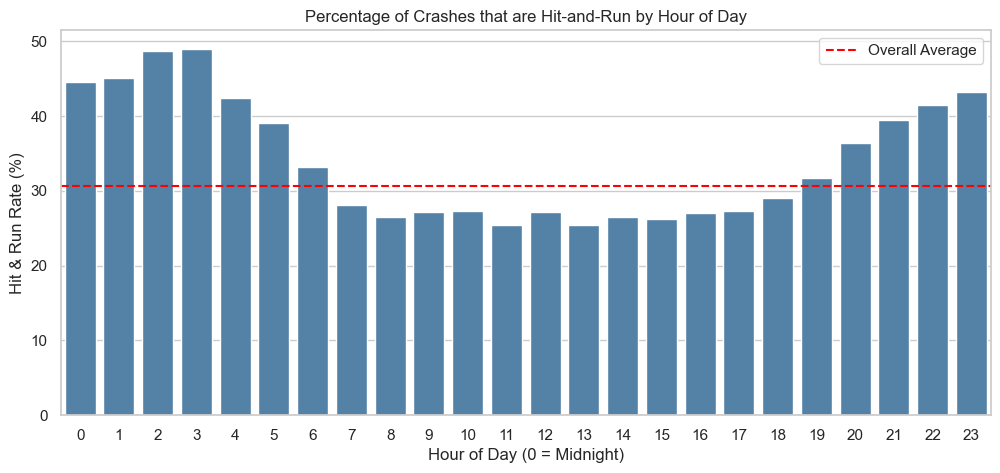

In [120]:
# Convert 'crash_hour' to numeric for proper sorting/plotting
df_train['crash_hour'] = pd.to_numeric(df_train['crash_hour'])

# Calculate the hit-and-run rate per hour
hourly_rates = df_train.groupby('crash_hour')['is_hit_and_run'].mean() * 100

plt.figure(figsize=(12, 5))
sns.barplot(x=hourly_rates.index, y=hourly_rates.values, color='steelblue')
plt.title('Percentage of Crashes that are Hit-and-Run by Hour of Day')
plt.ylabel('Hit & Run Rate (%)')
plt.xlabel('Hour of Day (0 = Midnight)')
plt.axhline(df_train['is_hit_and_run'].mean() * 100, color='red', linestyle='--', label='Overall Average')
plt.legend()
plt.show()

Notice the spike during late-night and early-morning hours? Let's also check the day of the week.

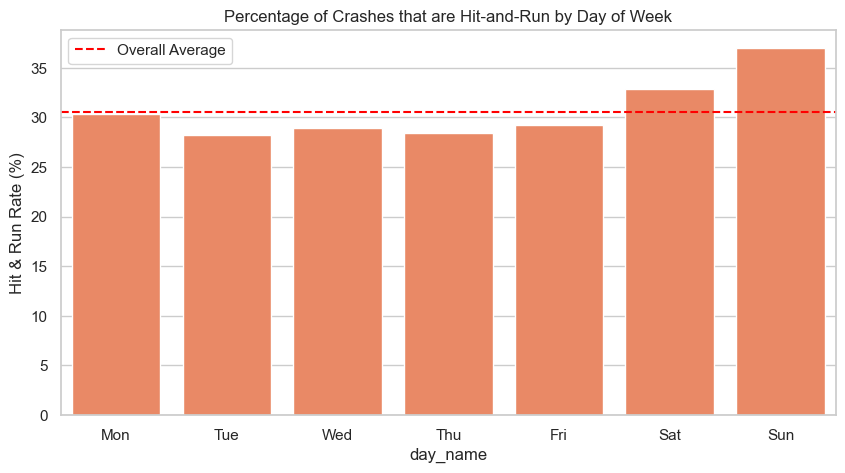

In [121]:
# In Chicago data, 1=Sunday, 2=Monday, ..., 7=Saturday
df_train['crash_day_of_week'] = pd.to_numeric(df_train['crash_day_of_week'])
day_mapping = {1: 'Sun', 2: 'Mon', 3: 'Tue', 4: 'Wed', 5: 'Thu', 6: 'Fri', 7: 'Sat'}
df_train['day_name'] = df_train['crash_day_of_week'].map(day_mapping)

day_rates = df_train.groupby('day_name')['is_hit_and_run'].mean().reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']) * 100

plt.figure(figsize=(10, 5))
sns.barplot(x=day_rates.index, y=day_rates.values, color='coral')
plt.title('Percentage of Crashes that are Hit-and-Run by Day of Week')
plt.ylabel('Hit & Run Rate (%)')
plt.axhline(df_train['is_hit_and_run'].mean() * 100, color='red', linestyle='--', label='Overall Average')
plt.legend()
plt.show()

Finally, let's look at `lighting_condition` to see if darkness plays a role, independent of the strict time of day.

/var/folders/vr/69185f_n1jd4wr0p8145ps1m8zr63m/T/ipykernel_62347/1665005583.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lighting_rates['mean'], y=lighting_rates.index, palette='viridis')


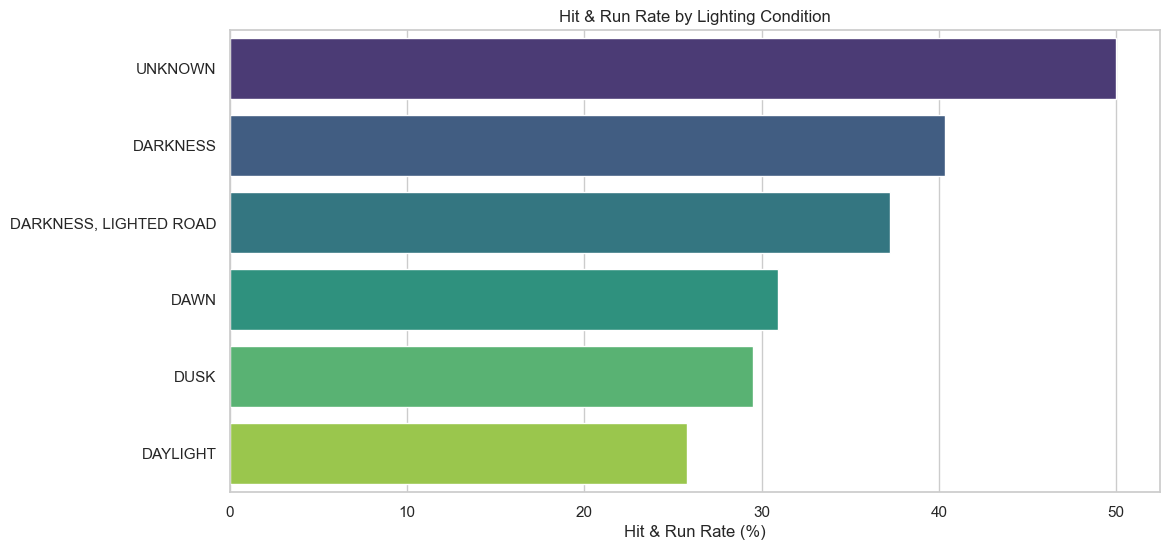

In [122]:
lighting_rates = df_train.groupby('lighting_condition')['is_hit_and_run'].agg(['mean', 'count'])
lighting_rates['mean'] = lighting_rates['mean'] * 100
# Filter out categories with very few crashes for clearer visualization
lighting_rates = lighting_rates[lighting_rates['count'] > 50].sort_values(by='mean', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=lighting_rates['mean'], y=lighting_rates.index, palette='viridis')
plt.title('Hit & Run Rate by Lighting Condition')
plt.xlabel('Hit & Run Rate (%)')
plt.ylabel('')
plt.show()

## 7. Nightlife Data Acquisition (Business Licenses)
To answer our primary research question, we need the locations of businesses that serve alcohol (bars, taverns, late-night venues). We will query the Chicago Business Licenses API for active licenses related to nightlife.

**Deduplication Strategy:** As noted during exploration, a single building might host multiple unique businesses (e.g., a restaurant on floor 1, a nightclub on floor 2), and a single business might hold multiple licenses (e.g., a Tavern license and a Late Hour license). 

To accurately capture nightlife density without overcounting, we will deduplicate the data by combining the `account_number` (the business owner) and geographic coordinates (`latitude`, `longitude`). This ensures that a single business with multiple licenses at the same location is counted only once, but two *different* businesses sharing the same building are both accurately represented in our density calculations.

In [123]:
import os
import requests
import geopandas as gpd
import pandas as pd

DOWNLOAD_NIGHTLIFE = False
NIGHTLIFE_FILE = "nightlife_licenses.parquet"

if DOWNLOAD_NIGHTLIFE:
    NIGHTLIFE_API_URL = "https://data.cityofchicago.org/resource/r5kz-chrr.json"
    # We want active (AAI) licenses for Taverns, Late Hour venues, and Consumption on Premises
    query = (
        "SELECT * "
        "WHERE license_status = \"AAI\" "
        "AND (license_description = \"Tavern\" OR license_description = \"Late Hour\" OR license_description = \"Consumption on Premises - Incidental Activity\") "
        "AND latitude IS NOT NULL AND longitude IS NOT NULL "
        "LIMIT 100000"
    )
    
    print("Fetching nightlife data...")
    response = requests.get(NIGHTLIFE_API_URL, params={"$query": query})
    response.raise_for_status()
    
    df_bars = pd.DataFrame(response.json())
    print(f"Successfully loaded {len(df_bars)} active nightlife licenses.")
    
    # Ensure coordinates are numeric
    df_bars["latitude"] = pd.to_numeric(df_bars["latitude"])
    df_bars["longitude"] = pd.to_numeric(df_bars["longitude"])
    
    # Convert to GeoDataFrame
    gdf_bars = gpd.GeoDataFrame(
        df_bars, 
        geometry=gpd.points_from_xy(df_bars.longitude, df_bars.latitude),
        crs="EPSG:4326"
    )
    
    # Deduplicate by account_number and coordinates
    # This ensures a business with multiple licenses at the same location is counted once,
    # but two DIFFERENT businesses at the same location are both counted.
    initial_count = len(gdf_bars)
    gdf_bars = gdf_bars.drop_duplicates(subset=["account_number", "latitude", "longitude"])
    print(f"Deduplicated: {initial_count} -> {len(gdf_bars)} unique businesses.")
    
    # Save to Parquet
    for col in gdf_bars.columns:
        if col not in ["geometry", "latitude", "longitude"]:
            gdf_bars[col] = gdf_bars[col].astype(str)
            
    gdf_bars.to_parquet(NIGHTLIFE_FILE)
    print("Saved nightlife data to Parquet.")
else:
    print("Loading nightlife data from Parquet...")
    gdf_bars = gpd.read_parquet(NIGHTLIFE_FILE)
    print(f"Loaded {len(gdf_bars)} nightlife locations.")

gdf_bars.head(3)

Loading nightlife data from Parquet...
Loaded 7594 nightlife locations.


,id,license_id,account_number,site_number,legal_name,doing_business_as_name,address,city,state,zip_code,...,expiration_date,license_approved_for_issuance,date_issued,license_status,latitude,longitude,location,ssa,application_created_date,geometry
0,2574556-20260416,3071723,423938,1,THE SPOT SOCIAL HOUR INC,THE SPOT SOCIAL HOUR,12217 S HALSTED ST 1,CHICAGO,IL,60628,...,2028-04-15T00:00:00.000,2026-03-31T00:00:00.000,2026-04-01T00:00:00.000,AAI,41.671818,-87.641561,"{'latitude': '41.67181817763099', 'longitude':...",nan,nan,POINT (-87.64156 41.67182)
1,2647350-20260416,3071957,456436,1,RIVER NORTH BREWPUB LLC,CRUSHED BY GIANTS,600 N MICHIGAN AVE 2 210,CHICAGO,IL,60611,...,2028-04-15T00:00:00.000,2026-03-30T00:00:00.000,2026-03-31T00:00:00.000,AAI,41.892593,-87.624334,"{'latitude': '41.89259322553828', 'longitude':...",nan,nan,POINT (-87.62433 41.89259)
2,2570243-20260416,3070583,86938,8,UNION LEAGUE CLUB OF CHICAGO,UNION LEAGUE CLUB OF CHICAGO,65 W JACKSON BLVD 1-23,CHICAGO,IL,60604,...,2028-04-15T00:00:00.000,2026-03-31T00:00:00.000,2026-04-01T00:00:00.000,AAI,41.878046,-87.630137,"{'latitude': '41.878045653481664', 'longitude'...",nan,nan,POINT (-87.63014 41.87805)


## 8. Nightlife Data Exploration
Before merging, let's explore the nightlife dataset to understand the distribution of venues across Chicago and the types of licenses they hold.

/var/folders/vr/69185f_n1jd4wr0p8145ps1m8zr63m/T/ipykernel_62347/2664756858.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=gdf_bars, y="license_description", palette="viridis", order=gdf_bars["license_description"].value_counts().index)


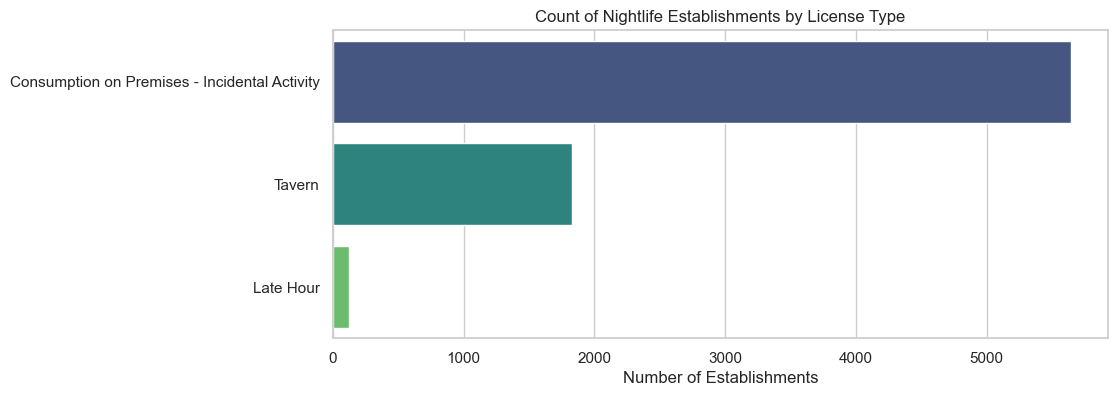

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

# Breakdown of license types
plt.figure(figsize=(10, 4))
sns.countplot(data=gdf_bars, y="license_description", palette="viridis", order=gdf_bars["license_description"].value_counts().index)
plt.title("Count of Nightlife Establishments by License Type")
plt.xlabel("Number of Establishments")
plt.ylabel("")
plt.show()

/var/folders/vr/69185f_n1jd4wr0p8145ps1m8zr63m/T/ipykernel_62347/908415406.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_zips.index, y=top_zips.values, palette="magma")


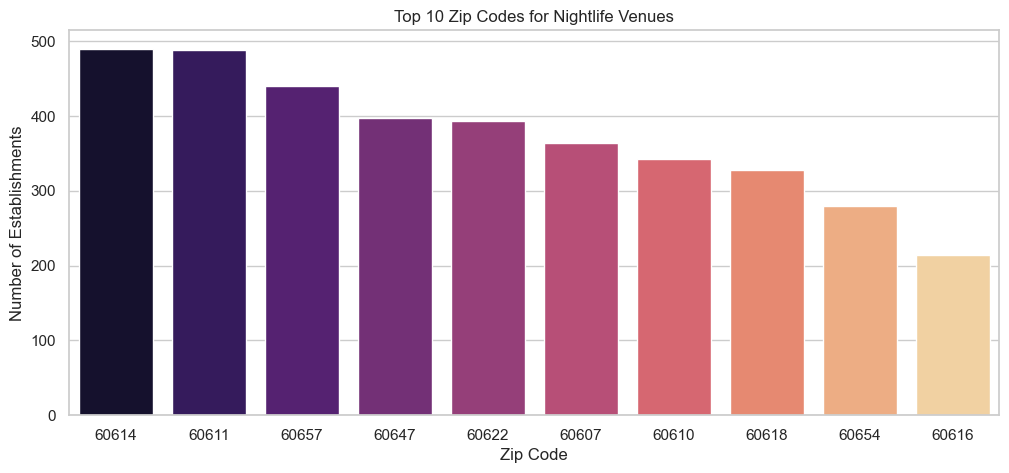

In [125]:
# Top 10 Zip Codes for nightlife
top_zips = gdf_bars["zip_code"].value_counts().head(10)
plt.figure(figsize=(12, 5))
sns.barplot(x=top_zips.index, y=top_zips.values, palette="magma")
plt.title("Top 10 Zip Codes for Nightlife Venues")
plt.xlabel("Zip Code")
plt.ylabel("Number of Establishments")
plt.show()

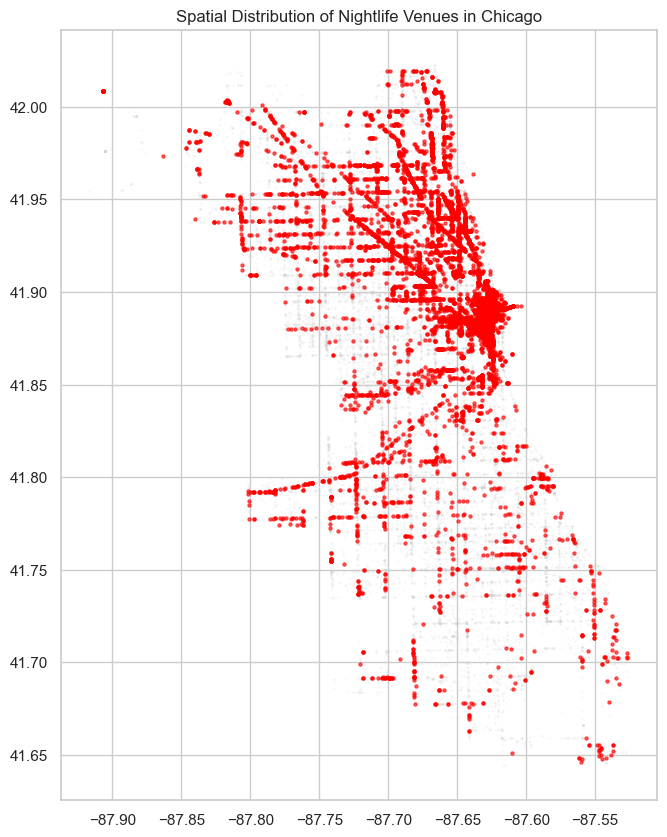

In [126]:
# Spatial distribution map: Crashes (background) vs Nightlife (red foreground)
fig, ax = plt.subplots(figsize=(10, 10))

# We use a sample of training crashes for a faster and cleaner background plot
df_train.sample(min(20000, len(df_train)), random_state=42).plot(ax=ax, markersize=1, alpha=0.1, color="lightgray")
gdf_bars.plot(ax=ax, markersize=5, alpha=0.6, color="red")

plt.title("Spatial Distribution of Nightlife Venues in Chicago")
plt.show()

## 9. Feature Engineering: Spatial Join (Nightlife Density)
We will now create our primary spatial feature: **Nightlife Density within 500 meters**.

To do this accurately, we must first reproject our data from a Geographic Coordinate System (degrees, EPSG:4326) to a Projected Coordinate System (meters). For Chicago, **UTM Zone 16N (EPSG:32616)** is an excellent choice as it preserves distances in meters.

We will use `geopandas` to:
1. Reproject both datasets to EPSG:32616.
2. Create a 500-meter buffer around every crash in the training set.
3. Perform a spatial join (`sjoin`) to count how many bars fall within each buffer.
4. Fill any crashes with 0 bars with `0`.

In [127]:
# 1. Reproject to UTM Zone 16N (meters)
df_train_proj = df_train.to_crs("EPSG:32616")
df_test_proj = df_test.to_crs("EPSG:32616")
gdf_bars_proj = gdf_bars.to_crs("EPSG:32616")

# 2. Create a 500-meter buffer around each crash
crashes_buffered_train = df_train_proj.copy()
crashes_buffered_train["geometry"] = crashes_buffered_train.geometry.buffer(500)

crashes_buffered_test = df_test_proj.copy()
crashes_buffered_test["geometry"] = crashes_buffered_test.geometry.buffer(500)

# 3. Spatial Join: Find all bars that intersect with the 500m crash buffers
joined_train = gpd.sjoin(crashes_buffered_train, gdf_bars_proj, how="inner", predicate="intersects")
joined_test = gpd.sjoin(crashes_buffered_test, gdf_bars_proj, how="inner", predicate="intersects")

# 4. Count the number of bars per crash
bar_counts_train = joined_train.groupby(joined_train.index).size()
bar_counts_test = joined_test.groupby(joined_test.index).size()

# 5. Add the new feature back to the training and testing sets
df_train["nightlife_density_500m"] = bar_counts_train
df_train["nightlife_density_500m"] = df_train["nightlife_density_500m"].fillna(0).astype(int)

df_test["nightlife_density_500m"] = bar_counts_test
df_test["nightlife_density_500m"] = df_test["nightlife_density_500m"].fillna(0).astype(int)

print("Spatial join complete for both Train and Test! Feature 'nightlife_density_500m' created.")


Spatial join complete for both Train and Test! Feature 'nightlife_density_500m' created.


## 10. Temporal Feature Engineering & Final Preparation
With our spatial feature created, we now need to finalize our temporal features before modeling. The `crash_date` is a string (e.g., `2025-05-09T13:44:00.000`), which machine learning models cannot interpret directly. 

We will parse this into two discrete numeric features:
1. **`hour_of_day`**: (0-23) to capture late-night drinking hours.
2. **`day_of_week`**: (0=Monday, 6=Sunday) to capture weekend effects.

Finally, we will select our core set of features for the model and drop the raw dates and coordinates.

In [128]:
import pandas as pd
import re

# 1. Select Only Necessary Features from the Start
# This immediately discards all irrelevant/noisy columns (like location, IDs, etc.)
raw_features_to_keep = [
    "nightlife_density_500m", 
    "crash_date", # We need this to extract time, but will drop it later
    "posted_speed_limit",
    "weather_condition",
    "lighting_condition",
    "roadway_surface_cond",
    "alignment",
    "traffic_control_device",
    "first_crash_type",
    "trafficway_type",
    "damage",
    "num_units",
    "injuries_total",
    "dooring_i",
    "is_hit_and_run" # Target variable placed explicitly at the very end
]

df_train_clean = df_train[raw_features_to_keep].copy()
df_test_clean = df_test[raw_features_to_keep].copy()

# 2. Parse Date/Time features and drop the original string
def prep_features(df):
    # Extract datetime
    crash_date_parsed = pd.to_datetime(df["crash_date"])
    
    # Insert new temporal features right before the target variable
    target_idx = df.columns.get_loc("is_hit_and_run")
    df.insert(target_idx, "hour_of_day", crash_date_parsed.dt.hour)
    df.insert(target_idx + 1, "day_of_week", crash_date_parsed.dt.dayofweek)
    df.insert(target_idx + 2, "crash_month", crash_date_parsed.dt.month)
    
    # Drop the raw string dates to prevent redundancy/leakage
    df = df.drop(columns=["crash_date"])
    return df

df_train_clean = prep_features(df_train_clean)
df_test_clean = prep_features(df_test_clean)

# 3. Clean Data and Handle Missing Values
def clean_data(df):
    df["dooring_i"] = df["dooring_i"].fillna("N")
    df["dooring_i"] = df["dooring_i"].apply(lambda x: 1 if x == "Y" else 0)
    
    df["injuries_total"] = pd.to_numeric(df["injuries_total"], errors="coerce").fillna(0)
    df["num_units"] = pd.to_numeric(df["num_units"], errors="coerce").fillna(1)
    df["posted_speed_limit"] = pd.to_numeric(df["posted_speed_limit"], errors="coerce").fillna(30)
    
    # Clean strings
    categorical_cols = [
        "weather_condition", "lighting_condition", "roadway_surface_cond", 
        "alignment", "traffic_control_device", "first_crash_type", 
        "trafficway_type", "damage"
    ]
    for col in categorical_cols:
        df[col] = df[col].astype(str).str.upper().str.strip()
    
    # Handle Remaining Missing Values
    missing = df.isnull().sum().sum()
    if missing > 0:
        print(f"Dropping {missing} rows with missing values...")
        df = df.dropna()
    
    return df

print("Cleaning Train Set...")
df_train_clean = clean_data(df_train_clean)
print("Cleaning Test Set...")
df_test_clean = clean_data(df_test_clean)

print(f"Cleaned Training Data Shape: {df_train_clean.shape}")
print(f"Cleaned Testing Data Shape: {df_test_clean.shape}")
df_train_clean.head(3)


Cleaning Train Set...
Cleaning Test Set...
Cleaned Training Data Shape: (175039, 17)
Cleaned Testing Data Shape: (43760, 17)


,nightlife_density_500m,posted_speed_limit,weather_condition,lighting_condition,roadway_surface_cond,alignment,traffic_control_device,first_crash_type,trafficway_type,damage,num_units,injuries_total,dooring_i,hour_of_day,day_of_week,crash_month,is_hit_and_run
72117,0,30,CLEAR,DAYLIGHT,DRY,STRAIGHT AND LEVEL,TRAFFIC SIGNAL,REAR END,NOT DIVIDED,"$501 - $1,500",2,0.0,0,13,4,5,1
22180,17,30,CLEAR,DAYLIGHT,DRY,STRAIGHT AND LEVEL,NO CONTROLS,PARKED MOTOR VEHICLE,PARKING LOT,"OVER $1,500",3,0.0,0,13,1,10,0
107004,9,15,SNOW,"DARKNESS, LIGHTED ROAD",SNOW OR SLUSH,STRAIGHT AND LEVEL,UNKNOWN,OTHER OBJECT,ALLEY,$500 OR LESS,1,0.0,0,22,6,1,0


## 11. Data Validation & Outlier Detection
Before feeding this data into a machine learning model, we must verify that our selected features do not contain nonsensical values (e.g., a speed limit of 999 mph, or negative values). 

**Note on dropped columns:** The raw Chicago Crashes dataset contains over 40 columns (like `crash_record_id`, `street_direction`, `beat_of_occurrence`, etc.). By explicitly defining our `features` list in the previous step, we have **already dropped** all irrelevant, noisy, or ID-based columns. We are now working strictly with our clean `X_train` matrix.

Let's inspect the numerical distributions (to spot outliers) and categorical frequencies (to spot weird typos).

In [129]:
import numpy as np
import matplotlib.pyplot as plt

print("--- NUMERICAL FEATURE DISTRIBUTION (Checking for Outliers) ---")
numerical_cols = [
    "nightlife_density_500m", "hour_of_day", "day_of_week", 
    "crash_month", "posted_speed_limit", "num_units", 
    "injuries_total", "dooring_i"
]
display(df_train_clean[numerical_cols].describe(percentiles=[0.01, 0.05, 0.95, 0.99]))

print("\n--- CATEGORICAL FEATURE FREQUENCIES (Checking for typos/rare categories) ---")
categorical_cols = [
    "weather_condition", "lighting_condition", "roadway_surface_cond",
    "alignment", "traffic_control_device", "first_crash_type",
    "trafficway_type", "damage"
]
for col in categorical_cols:
    print(f"\n{col.upper()}:")
    display(df_train_clean[col].value_counts().head(10))

print("\n--- TARGET VARIABLE DISTRIBUTION ---")
display(df_train_clean["is_hit_and_run"].value_counts(normalize=True) * 100)

# Outlier Handling (Speed Limit Example)
outlier_speed_mask = df_train_clean["posted_speed_limit"] > 80
if outlier_speed_mask.any():
    print(f"\nFound {outlier_speed_mask.sum()} rows with posted_speed_limit > 80 mph. Capping at 80.")
    df_train_clean.loc[outlier_speed_mask, "posted_speed_limit"] = 80
    df_test_clean.loc[df_test_clean["posted_speed_limit"] > 80, "posted_speed_limit"] = 80


--- NUMERICAL FEATURE DISTRIBUTION (Checking for Outliers) ---


,nightlife_density_500m,hour_of_day,day_of_week,crash_month,posted_speed_limit,num_units,injuries_total,dooring_i
count,175039.000000,175039.000000,175039.000000,175039.000000,175039.000000,175039.000000,175039.000000,175039.000000
mean,26.513566,13.153143,2.989088,6.584047,28.529785,2.036106,0.229240,0.002405
std,58.587482,5.579898,1.952634,3.342407,5.479050,0.438142,0.618066,0.048984
min,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
1%,0.000000,0.000000,0.000000,1.000000,10.000000,1.000000,0.000000,0.000000
5%,0.000000,2.000000,0.000000,1.000000,15.000000,1.000000,0.000000,0.000000
50%,7.000000,14.000000,3.000000,7.000000,30.000000,2.000000,0.000000,0.000000
95%,146.000000,22.000000,6.000000,12.000000,35.000000,3.000000,1.000000,0.000000
99%,329.000000,23.000000,6.000000,12.000000,40.000000,4.000000,3.000000,0.000000
max,467.000000,23.000000,6.000000,12.000000,70.000000,18.000000,19.000000,1.000000



--- CATEGORICAL FEATURE FREQUENCIES (Checking for typos/rare categories) ---

WEATHER_CONDITION:


weather_condition
CLEAR                    137076
UNKNOWN                   14139
RAIN                      12604
CLOUDY/OVERCAST            4886
SNOW                       4452
FREEZING RAIN/DRIZZLE       762
OTHER                       651
FOG/SMOKE/HAZE              176
SLEET/HAIL                  161
BLOWING SNOW                105
Name: count, dtype: int64


LIGHTING_CONDITION:


...

trafficway_type
NOT DIVIDED                        70286
DIVIDED - W/MEDIAN (NOT RAISED)    24379
FOUR WAY                           22304
ONE-WAY                            19964
PARKING LOT                        11161
DIVIDED - W/MEDIAN BARRIER          8666
OTHER                               4304
T-INTERSECTION                      4220
ALLEY                               2889
UNKNOWN                             2381
Name: count, dtype: int64


DAMAGE:


damage
OVER $1,500      126541
$501 - $1,500     32467
$500 OR LESS      16031
Name: count, dtype: int64


--- TARGET VARIABLE DISTRIBUTION ---


is_hit_and_run
0    69.441096
1    30.558904
Name: proportion, dtype: float64

## 12. Preprocessing Pipeline: Encoding & Scaling
To test multiple machine learning algorithms (both tree-based and distance/linear-based), we must properly encode and scale our features.

**1. Categorical Encoding (One-Hot):**
We treat temporal features (`hour_of_day`, `day_of_week`, `crash_month`) as categorical. A linear model cannot understand that month 12 (Dec) is next to month 1 (Jan) if they are just numbers. By one-hot encoding them, the model can independently learn the risk of "2:00 AM" or "Saturday".

**2. Target Separation & Dummy Alignment:**
We separate `X` and `y`. When creating dummy variables, we must align the training and testing sets to ensure they have the exact same columns (in case a rare weather condition only appeared in one set).

**3. Standardization:**
Algorithms like Logistic Regression or KNN are highly sensitive to scale (e.g., a speed limit of 50 would overpower a density of 2). We use `StandardScaler` to give all true numerical features a mean of 0 and variance of 1. *Crucially, we fit the scaler ONLY on the training data to prevent data leakage.*

In [130]:
import pandas as pd
import re
from sklearn.preprocessing import StandardScaler

# 1. Define feature types
categorical_cols = [
    "hour_of_day", "day_of_week", "crash_month", # Treated as categorical!
    "weather_condition", "lighting_condition", "roadway_surface_cond", 
    "alignment", "traffic_control_device", "first_crash_type", 
    "trafficway_type", "damage"
]

numerical_cols = [
    "nightlife_density_500m", 
    "posted_speed_limit", 
    "num_units", 
    "injuries_total"
]
if "dooring_i" in df_train_clean.columns:
    numerical_cols.append("dooring_i") # Binary, but safe to treat as numerical/pass-through

# 2. Separate X and y
X_train = df_train_clean.drop(columns=["is_hit_and_run"])
y_train = df_train_clean["is_hit_and_run"].copy()

X_test = df_test_clean.drop(columns=["is_hit_and_run"])
y_test = df_test_clean["is_hit_and_run"].copy()

# 3. One-Hot Encoding
# Convert specified columns to strings so get_dummies treats them as categories
for col in categorical_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# 4. Dummy Alignment
# Ensure Test set has the exact same columns as Train set (fill missing with 0)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

# 5. Clean Column Names (Crucial for XGBoost/LightGBM)
X_train.columns = [re.sub(r"[^a-zA-Z0-9]", "_", col).lower().strip("_") for col in X_train.columns]
X_train.columns = [re.sub(r"_+", "_", col) for col in X_train.columns]
X_test.columns = X_train.columns # Ensure perfect match

# 6. Standardization
# Fit ONLY on training data to prevent leakage, then transform both
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(f"Final Preprocessed X_train shape: {X_train.shape}")
print(f"Final Preprocessed X_test shape:  {X_test.shape}")
print(f"Number of final features: {len(X_train.columns)}")
X_train.head(3)

Final Preprocessed X_train shape: (175039, 127)
Final Preprocessed X_test shape:  (43760, 127)
Number of final features: 127


,nightlife_density_500m,posted_speed_limit,num_units,injuries_total,dooring_i,hour_of_day_1,hour_of_day_10,hour_of_day_11,hour_of_day_12,hour_of_day_13,...,trafficway_type_parking_lot,trafficway_type_ramp,trafficway_type_roundabout,trafficway_type_t_intersection,trafficway_type_traffic_route,trafficway_type_unknown,trafficway_type_unknown_intersection_type,trafficway_type_y_intersection,damage_501_1_500,damage_over_1_500
72117,-0.452548,0.268335,-0.082408,-0.3709,-0.049102,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
22180,-0.162383,0.268335,2.199962,-0.3709,-0.049102,False,False,False,False,True,...,True,False,False,False,False,False,False,False,False,True
107004,-0.298931,-2.469374,-2.364778,-0.3709,-0.049102,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
